<a href="https://colab.research.google.com/github/anshitatomar99-svg/video-virality-prediction/blob/main/virality_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import glob

# 1. Automatically find ALL .csv files uploaded to Colab
file_names = glob.glob('*.csv')

dataframes = []

# 2. Loop through every file found
for file in file_names:
    # We use latin1 encoding because some countries have special characters that break the default reader
    temp_df = pd.read_csv(file, encoding='latin1')
    # Create a new column to track the country (e.g., 'US', 'JP')
    temp_df['country_code'] = file[:2]
    dataframes.append(temp_df)

# 3. Stitch them all together into one massive master DataFrame
df = pd.concat(dataframes, ignore_index=True)

print(f"Successfully combined {len(file_names)} files!")
print(f"Total rows in new dataset: {len(df)}")

Successfully combined 10 files!
Total rows in new dataset: 375942


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the Data
# Using the India YouTube trending dataset you uploaded


# 2. Define Features (X) and Target (y)
# These are the numeric columns available in your specific dataset
features = ['likes', 'dislikes', 'comment_count']

# Create the 'is_viral' column automatically
# (Labels a video as True if its views are above the dataset's median)
df['is_viral'] = df['views'] > df['views'].median()
target = 'is_viral'

X = df[features]
y = df[target]

# 3. Split into Training and Testing Sets
# 80% of data used for training, 20% held back for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions and Evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Performance Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 88.59%

Detailed Performance Report:
              precision    recall  f1-score   support

       False       0.89      0.88      0.89     37716
        True       0.88      0.89      0.89     37473

    accuracy                           0.89     75189
   macro avg       0.89      0.89      0.89     75189
weighted avg       0.89      0.89      0.89     75189



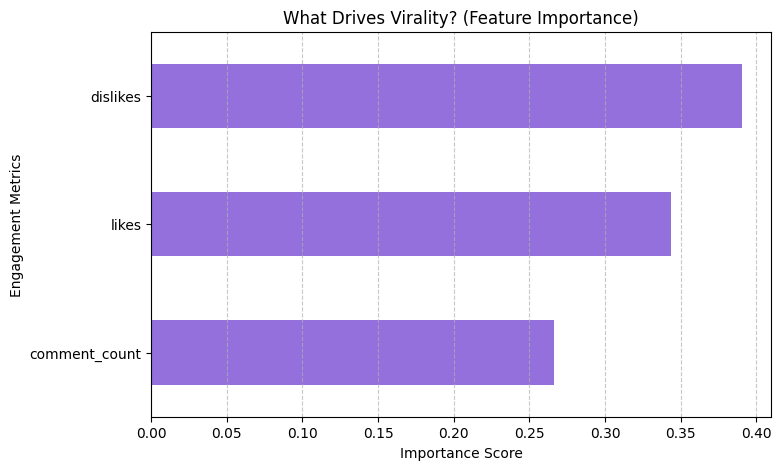

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract the importance scores from your trained model
importances = pd.Series(model.feature_importances_, index=features)

# Create a horizontal bar chart
importances.sort_values(ascending=True).plot(kind='barh', color='mediumpurple', figsize=(8, 5))
plt.title('What Drives Virality? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Engagement Metrics')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()